<a href="https://colab.research.google.com/github/giugnom3/Algorithms/blob/main/W7HW_GiugnoMaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Demo on ANN for Prediction

Import Libraries

In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

Load the Gila River Dataset

In [24]:
data = pd.read_csv('gila_river.csv')
data.head()
data.shape

(1034, 4)

Define Input Features and Target Variable

In [25]:
X = data.drop(columns=['y(t)'])
y = data['y(t)']

Split the Data into Training and Testing Sets

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Standardize the Input Features

In [27]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Initialize the MLP Regressor Model

In [28]:
mlp = MLPRegressor(hidden_layer_sizes=(64,64), max_iter=3000, random_state=42)

Train the Neural Network Model

In [29]:
mlp.fit(X_train, y_train)

MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=3000, random_state=42)

Generate Predictions for Training and Testing Data

In [30]:
y_train_pred = mlp.predict(X_train)
y_test_pred = mlp.predict(X_test)

Evaluate Model Performance Using Mean Squared Error

In [31]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Training MSE: {mse_train}")
print(f"Testing MSE: {mse_test}")

Training MSE: 61200.11502134433
Testing MSE: 24308.48773391334


Plot the MLP Convergence Curve

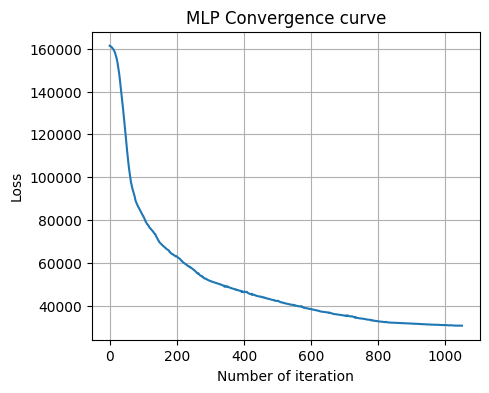

In [32]:
plt.figure(figsize=(5, 4))
plt.plot(mlp.loss_curve_)
plt.title('MLP Convergence curve')
plt.xlabel('Number of iteration')
plt.ylabel('Loss')
plt.grid(True)

plt.show()

Plot Actual vs Predicted Response for the Testing Set

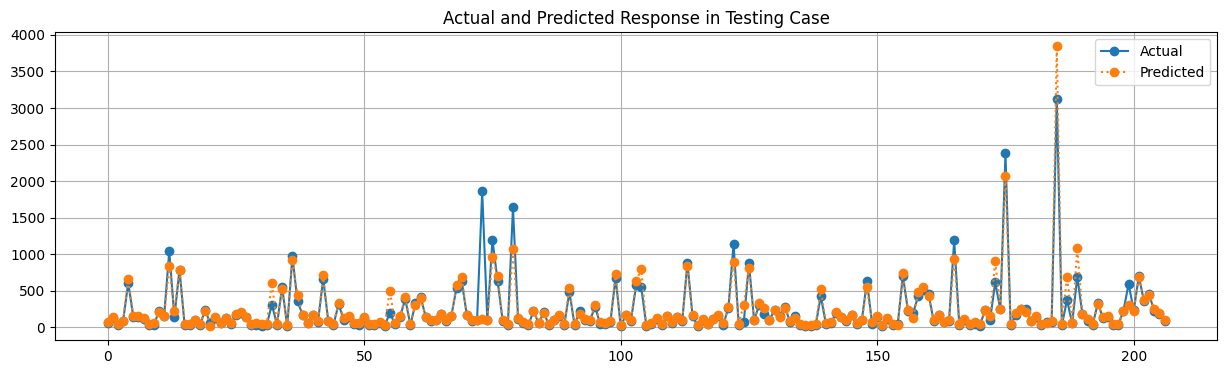

In [33]:
t = range(len(y_test))

plt.figure(figsize=(15,4))
plt.plot(t, y_test, label='Actual', linestyle='-', marker='o')
plt.plot(t, y_test_pred, label='Predicted', linestyle=':', marker='o')
plt.title('Actual and Predicted Response in Testing Case')
plt.legend()
plt.grid(True)

plt.show()

Plot Prediction Error for the Testing Set

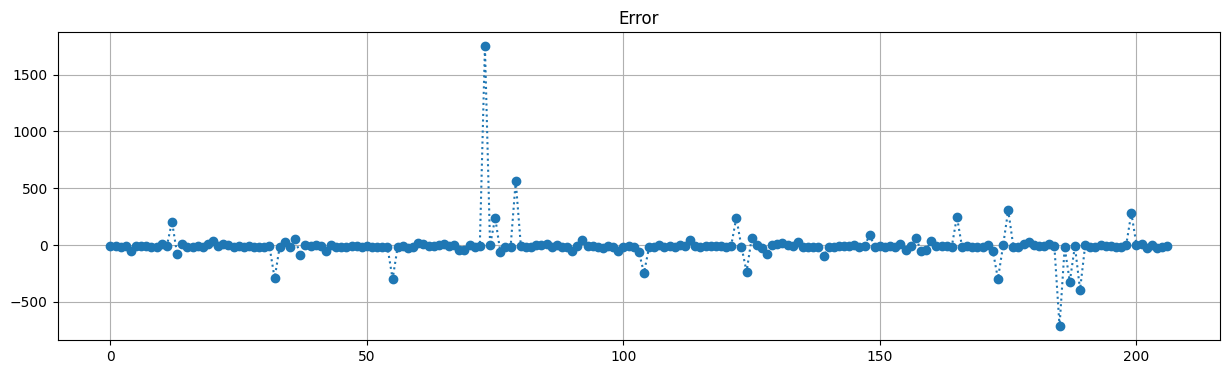

In [34]:
t = range(len(y_test))

plt.figure(figsize=(15,4))
plt.plot(t, y_test - y_test_pred, linestyle=':', marker='o')
plt.title('Error')
# plt.legend()
plt.grid(True)

plt.show()

Plot Actual vs Predicted Response for the Training Set

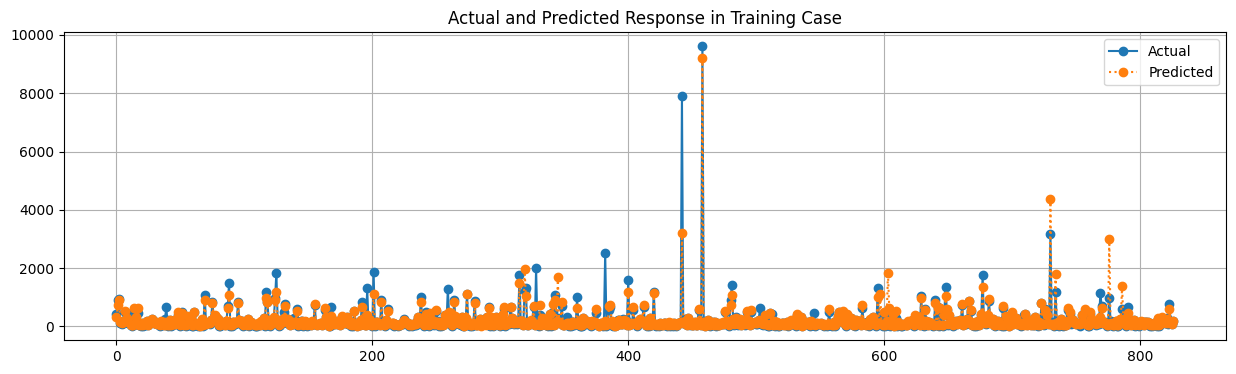

In [35]:
t = range(len(y_train))

plt.figure(figsize=(15,4))
plt.plot(t, y_train, label='Actual', linestyle='-', marker='o')
plt.plot(t, y_train_pred, label='Predicted', linestyle=':', marker='o')
plt.title('Actual and Predicted Response in Training Case')
plt.legend()
plt.grid(True)

plt.show()